# EDA — CNN/DailyMail Corpus

Exploratory analysis of the cleaned document corpus loaded into BigQuery.
Outputs from this notebook feed directly into the Architecture & Agent Design Report.

**Prerequisites:** Run `python -m scripts.01_ingest_data` before opening this notebook.

In [1]:
import sys
sys.path.insert(0, "..")

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import Counter
from itertools import chain

from config.settings import get_settings
from src.gcp.bq_client import BQClient

settings = get_settings()
bq = BQClient()

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

## 1. Load Data

In [2]:
sql = f"""
SELECT doc_id, text, reference_summary, token_count, lang, ingested_at
FROM `{bq.table_ref('documents_clean')}`
"""

rows = bq.query(sql)
df = pd.DataFrame(rows)
df["ingested_at"] = pd.to_datetime(df["ingested_at"])
df["char_count"] = df["text"].str.len()
df["sent_count"] = df["text"].str.count(r"[.!?]+")
df["summary_token_count"] = df["reference_summary"].str.split().str.len()

print(f"Total documents : {len(df):,}")
print(f"Columns         : {list(df.columns)}")
df.head(3)

Total documents : 50
Columns         : ['doc_id', 'text', 'reference_summary', 'token_count', 'lang', 'ingested_at', 'char_count', 'sent_count', 'summary_token_count']


,doc_id,text,reference_summary,token_count,lang,ingested_at,char_count,sent_count,summary_token_count
0,472d4d19-a4a6-4bce-ad20-01240de5c0aa,"LONDON, England -- Chelsea are waiting on the ...",Chelsea are still waiting on the fitness of En...,183,en,2026-05-22 07:27:22.273916+00:00,1088,9,40
1,eea9d395-640d-4611-ace5-e876eddd8d31,"SAN FRANCISCO, California (CNN) -- A magnitude...","2,000 customers without electricity, power com...",193,en,2026-05-22 07:27:22.273747+00:00,1163,24,46
2,ab20bc7b-cb1f-4f68-b29c-47280ddfa1d9,"LAGOS, Nigeria (Reuters) -- Nigeria's televisi...","Anthony Ogadje, 25, reportedly drowned in Sher...",227,en,2026-05-22 07:27:22.273882+00:00,1439,14,28


## 2. Corpus-Level Statistics

In [3]:
stats = df[["token_count", "char_count", "sent_count", "summary_token_count"]].describe().round(1)
print(stats.to_string())

       token_count  char_count  sent_count  summary_token_count
count         50.0        50.0        50.0                 50.0
mean         609.8      3603.1        36.9                 42.2
std          297.3      1723.5        18.0                  7.4
min          183.0      1088.0         9.0                 27.0
25%          356.2      2138.0        24.2                 38.2
50%          628.5      3655.0        34.0                 42.5
75%          765.8      4666.0        50.0                 47.8
max         1665.0      9212.0        85.0                 56.0


## 3. Document Length Distribution (tokens)

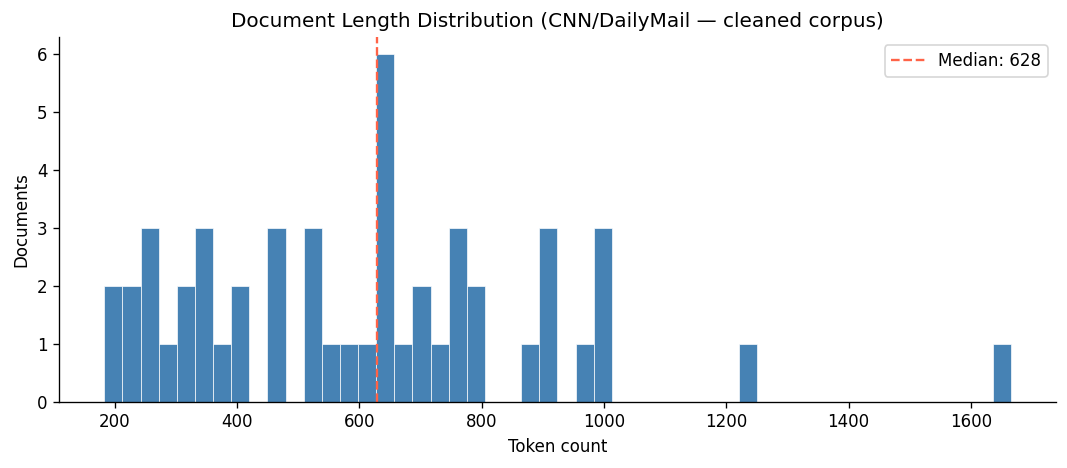

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df["token_count"], bins=50, color="steelblue", edgecolor="white", linewidth=0.4)
ax.axvline(df["token_count"].median(), color="tomato", linestyle="--", linewidth=1.4,
           label=f"Median: {df['token_count'].median():.0f}")
ax.set_xlabel("Token count")
ax.set_ylabel("Documents")
ax.set_title("Document Length Distribution (CNN/DailyMail — cleaned corpus)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend()
plt.tight_layout()
plt.savefig("../docs/eda_token_distribution.png", bbox_inches="tight")
plt.show()

## 4. Sentence Count Distribution

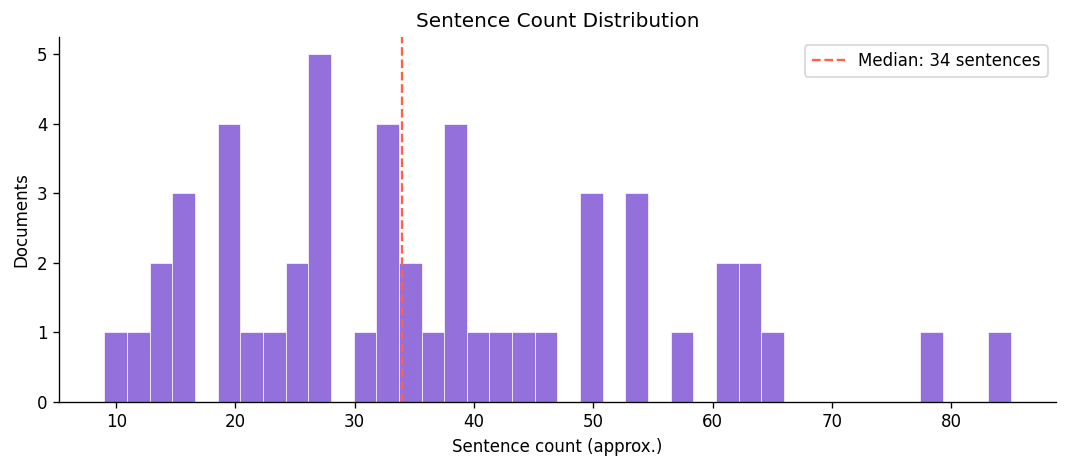

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df["sent_count"], bins=40, color="mediumpurple", edgecolor="white", linewidth=0.4)
ax.axvline(df["sent_count"].median(), color="tomato", linestyle="--", linewidth=1.4,
           label=f"Median: {df['sent_count'].median():.0f} sentences")
ax.set_xlabel("Sentence count (approx.)")
ax.set_ylabel("Documents")
ax.set_title("Sentence Count Distribution")
ax.legend()
plt.tight_layout()
plt.savefig("../docs/eda_sentence_distribution.png", bbox_inches="tight")
plt.show()

## 5. Top 20 Unigrams & Bigrams

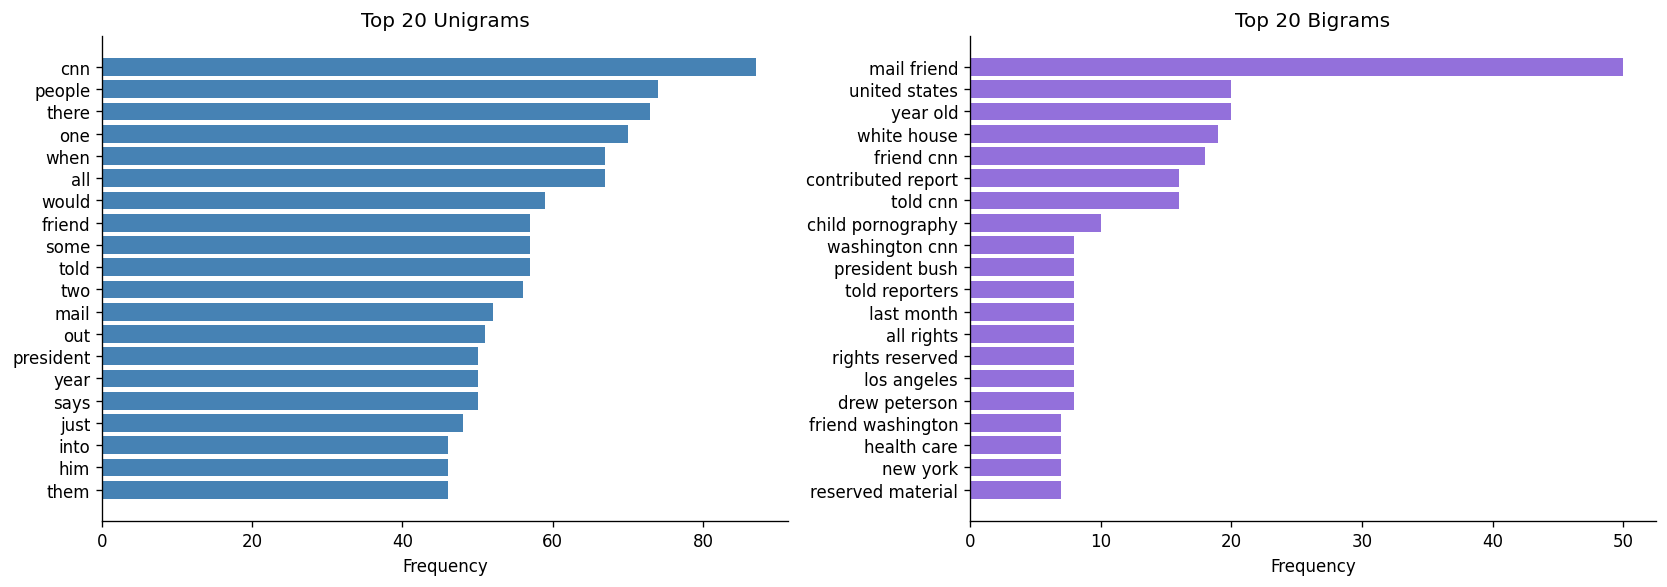

In [6]:
STOPWORDS = {
    "the", "a", "an", "and", "or", "but", "in", "on", "at", "to", "for",
    "of", "with", "is", "was", "are", "were", "he", "she", "they", "it",
    "his", "her", "their", "this", "that", "have", "has", "had", "be",
    "been", "by", "from", "as", "said", "will", "i", "we", "you", "not",
    "--", "also", "who", "its", "about", "up", "after", "more", "which",
}

def tokenize(text: str) -> list[str]:
    import re
    return [w.lower() for w in re.findall(r"\b[a-zA-Z]{3,}\b", text)
            if w.lower() not in STOPWORDS]

# Sample 300 docs for speed
sample = df.sample(min(300, len(df)), random_state=42)
all_tokens = list(chain.from_iterable(tokenize(t) for t in sample["text"]))

unigrams = Counter(all_tokens).most_common(20)
bigrams  = Counter(
    zip(all_tokens, all_tokens[1:])
).most_common(20)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

words, counts = zip(*unigrams)
axes[0].barh(list(reversed(words)), list(reversed(counts)), color="steelblue")
axes[0].set_title("Top 20 Unigrams")
axes[0].set_xlabel("Frequency")

bg_labels = [f"{a} {b}" for a, b in [p for p, _ in bigrams]]
bg_counts = [c for _, c in bigrams]
axes[1].barh(list(reversed(bg_labels)), list(reversed(bg_counts)), color="mediumpurple")
axes[1].set_title("Top 20 Bigrams")
axes[1].set_xlabel("Frequency")

plt.tight_layout()
plt.savefig("../docs/eda_ngrams.png", bbox_inches="tight")
plt.show()

## 6. Vocabulary Size

In [7]:
vocab = set(all_tokens)
print(f"Unique tokens (sample of {len(sample)} docs) : {len(vocab):,}")
print(f"Total tokens  (sample)                     : {len(all_tokens):,}")
print(f"Type-token ratio                           : {len(vocab)/len(all_tokens):.3f}")

Unique tokens (sample of 50 docs) : 5,406
Total tokens  (sample)                     : 18,002
Type-token ratio                           : 0.300


## 7. Summary Token Count Distribution

Helps calibrate `max_output_tokens` for the Gemini summarizer.

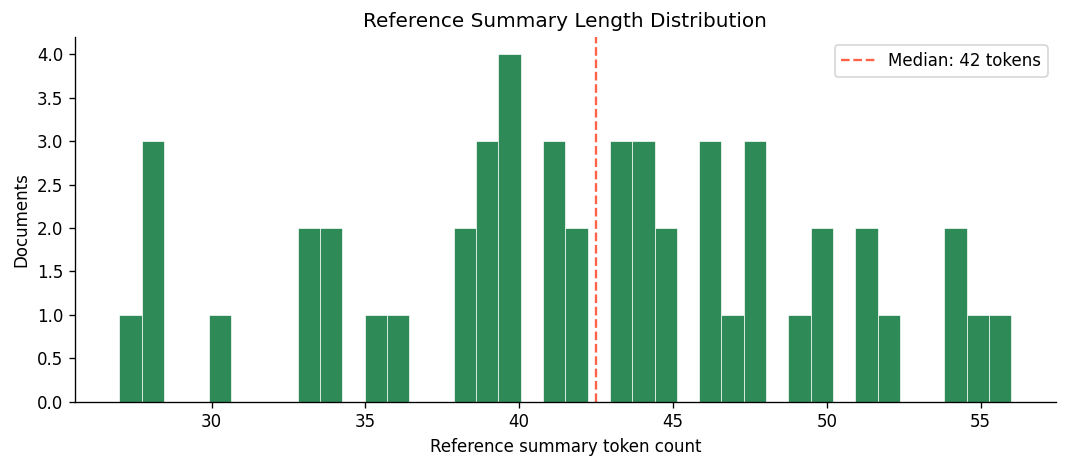

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df["summary_token_count"].dropna(), bins=40, color="seagreen", edgecolor="white", linewidth=0.4)
ax.axvline(df["summary_token_count"].median(), color="tomato", linestyle="--", linewidth=1.4,
           label=f"Median: {df['summary_token_count'].median():.0f} tokens")
ax.set_xlabel("Reference summary token count")
ax.set_ylabel("Documents")
ax.set_title("Reference Summary Length Distribution")
ax.legend()
plt.tight_layout()
plt.savefig("../docs/eda_summary_length.png", bbox_inches="tight")
plt.show()

## 8. Sample Documents

In [9]:
pd.set_option("display.max_colwidth", 300)

sample_docs = df.sample(5, random_state=7)[["doc_id", "token_count", "text", "reference_summary"]]

for _, row in sample_docs.iterrows():
    print(f"{'─'*70}")
    print(f"doc_id      : {row['doc_id']}")
    print(f"token_count : {row['token_count']}")
    print(f"article     : {row['text'][:400]}...")
    print(f"summary     : {row['reference_summary']}")
    print()

──────────────────────────────────────────────────────────────────────
doc_id      : 925225fa-c272-4d14-9e38-fad43f24db68
token_count : 378
article     : JOHANNESBURG, South Africa -- South African fast bowler Dale Steyn took a career-best five for 34 as the Proteas took a tight grip on the first test against New Zealand in Johannesburg. Steyn's career-best 5-34 was his fourth five-wicket haul in 14 tests. New Zealand were bowled out for 118 in reply to South Africa's 226 and the home side piled on the agony by reaching 179 for two in their second ...
summary     : South Africa lead New Zealand by 287 with 8 wickets standing in the 1st test .
The Proteas reach 179-2 in their second innings after the Kiwis are 118 all out .
South African paceman Dale Steyn takes a career-best 5-34.

──────────────────────────────────────────────────────────────────────
doc_id      : b5bded83-b2db-4c65-b8c8-48d44aa55352
token_count : 414
article     : WASHINGTON (CNN) -- Doctors removed five small polyps

## 9. Key Takeaways

Fill in after running the notebook:

| Metric | Value |
|---|---|
| Total docs (cleaned) | ??? |
| Median token count | ??? |
| Median sentence count | ??? |
| Median summary length | ??? tokens |
| Vocabulary size (sample) | ??? |
| Docs likely needing map-reduce (> 3000 tokens) | ??? |

**Observations for the report:**
- ...
- ...

**Charts saved to `docs/`:**
- `eda_token_distribution.png`
- `eda_sentence_distribution.png`
- `eda_ngrams.png`
- `eda_summary_length.png`